<a href="https://colab.research.google.com/github/desireesosa/SimulacionII/blob/main/MCM_AlgoritmodeMetropolis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>MARKOV CHAIN MONTE CARLO</h1>
<h3><i>Metropolis-Hastings</i></h3>

<p>
El algoritmo de Metropolis-Hastings es un método de cadenas de Markov Monte Carlo (MCMC) para generar muestras a partir de distribuciones de probabilidad que son demasiado complejas para ser muestreadas directamente.
</p>

> **La intuición fundamental** es que Metropolis-Hastings solo requiere la densidad objetivo hasta una constante de normalización, que es exactamente la situación habitual en la inferencia bayesiana donde el denominador de la distribución a posteriori resulta intratable.

<p>Se ha convertido en uno de los algoritmos más importantes de la estadística computacional, permitiendo la inferencia bayesiana en prácticamente todas las disciplinas científicas.</p>

<h3>Metodología</h3>

<p>
El algoritmo construye una cadena de Markov cuya distribución estacionaria es igual a la distribución objetivo $p(x)$. En cada iteración, se extrae un candidato $x'$ a partir de una distribución de propuesta $q(x' \mid x_t)$ y luego se acepta con probabilidad:
</p>

$$\alpha = \min \left( 1, \frac{p(x') q(x_t \mid x')}{p(x_t) q(x' \mid x_t)} \right)$$

<h3>Casos de uso</h3>

<div style="background-color: #f8f9fa; border-left: 5px solid #34a853; padding: 15px; border-radius: 4px;">
  <ul style="margin: 0; padding-left: 20px;">
    <li><b>Inferencia posterior bayesiana:</b> Cuando la distribución a posteriori no puede derivarse analíticamente (modelos jerárquicos o priores no conjugadas).</li>
    <li><b>Constantes de normalización intratables:</b> Aplicable cuando la distribución se conoce solo hasta un factor de proporcionalidad.</li>
    <li><b>Distribuciones flexibles:</b> Soporta objetivos continuos arbitrarios, multimodales y de alta dimensión.</li>
    <li><b>Sin requisitos del Muestreo de Gibbs:</b> No requiere disponer de las distribuciones condicionales completas.</li>
  </ul>
</div>


<h3> Código del Algoritmo de Metropolis </h3>

<p>Usando como prueba la función de dos dimensiones dada en clase.</p>

$$Z = c \cdot \exp\left( -\frac{x_1^2 x_2^2 + x_1^2 + x_2^2 - 8x_1 - 8x_2}{2} \right)$$

In [25]:
#Programa utilizando el algoritmo de metropolis-hastings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [30]:
def funciontarget(x):
    x, y = x[0], x[1]
    exp_val = -(x**2 * y**2 + x**2 + y**2 - 8*x - 8*y) / 2.0
    return np.exp(exp_val)

In [32]:
def metropolishast(n_iter, p_ini, desviacion_prop=0.4):
    historial = np.zeros((n_iter, 2))
    p_act = np.array(p_ini, dtype=float)
    historial[0] = p_act
    aceptaciones = 0

    for i in range(1, n_iter):
        propuesta = p_act + np.random.normal(0, desviacion_prop, size=2)
        val_actual = funciontarget(p_act)
        val_candidato = funciontarget(propuesta)

        if val_actual > 0:
            prob_aceptacion = min(1.0, val_candidato / val_actual)
        else:
            prob_aceptacion = 1.0

        if np.random.rand() <= prob_aceptacion:
            p_act = propuesta
            aceptaciones += 1

        historial[i] = p_act

    tasa = (aceptaciones / n_iter) * 100
    print(f"Porcentaje de aceptación: {tasa:.2f}%")
    return historial

np.random.seed(123)
iteraciones = 15000
puntos = metropolishast(iteraciones, [1.0, 1.0])

Porcentaje de aceptación: 58.91%


<h3> Gráfica de la función </h3>

Obtener la grafica en 2D y 3D de la función anterior.

In [33]:
#Programa que grafica a la funcion de dos dimensiones
c_norm = 4.9465e-5
x = y = np.linspace(-1, 5, 200)
X, Y = np.meshgrid(x, y)
Z = c_norm * np.exp(-(X**2 * Y**2 + X**2 + Y**2 - 8*X - 8*Y) / 2.0)

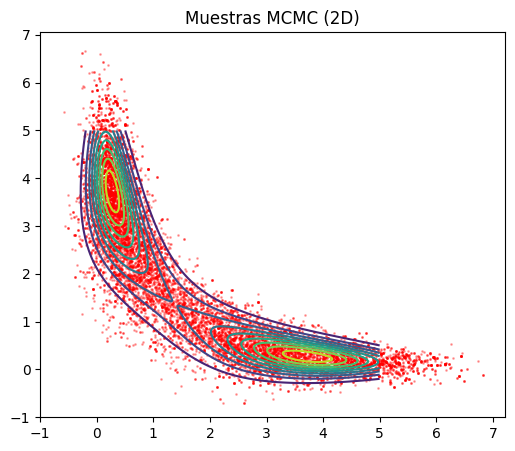

In [42]:
plt.figure(figsize=(6, 5))
plt.contour(X, Y, Z, levels=10, cmap='viridis')
plt.scatter(puntos[1000:, 0], puntos[1000:, 1], s=1, c='red', alpha=0.3)
plt.title('Muestras MCMC (2D)')
plt.show()

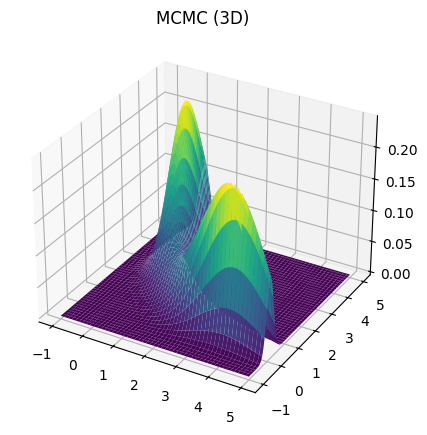

In [44]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_title('MCMC (3D)')
plt.show()

Metropolis-Hastings y otros algoritmos Montecarlo en cadena de Markov se usan generalmente para el muestreo de distribuciones multidimensionales, especialmente cuando el número de dimensiones es alto. Para las distribuciones unidimensionales, generalmente hay otros métodos (por ejemplo, el muestreo de rechazo adaptativo) que pueden generar directamente muestras independientes de la distribución, y estos están libres del problema de las muestras autocorrelacionadas, inherente a los métodos Montecarlo en cadena de Markov.